In [8]:
# Step 0: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess

# Function to push to GitHub after each main step
def push_to_github(commit_message="Update project progress"):
    subprocess.run(["git", "add", "."])
    subprocess.run(["git", "commit", "-m", commit_message])
    subprocess.run(["git", "push"])
    

In [9]:
# Step 1: Load dataset
df = pd.read_csv(r'C:\Users\Sudheera\Documents\Project -1\Online_Retail.csv', encoding='latin1')

# Quick check
print(df.head())

# Push to GitHub
push_to_github("Step 1: Loaded dataset")

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

    InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/10 8:26       2.55     17850.0  United Kingdom  
1  12/1/10 8:26       3.39     17850.0  United Kingdom  
2  12/1/10 8:26       2.75     17850.0  United Kingdom  
3  12/1/10 8:26       3.39     17850.0  United Kingdom  
4  12/1/10 8:26       3.39     17850.0  United Kingdom  


In [10]:
# Step 2: Data Cleaning

# Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove rows where Quantity <= 0 or UnitPrice <= 0
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Strip extra spaces in Description
df['Description'] = df['Description'].str.strip()

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True)

# Check cleaned data
print(df.info())
print(df.describe())

# Push to GitHub
push_to_github("Step 2: Data cleaning completed")

C:\Users\Sudheera\AppData\Local\Temp\ipykernel_1180\1052528458.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True)


<class 'pandas.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  str           
 1   StockCode    397884 non-null  str           
 2   Description  397884 non-null  str           
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[us]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 27.3 MB
None
            Quantity                 InvoiceDate      UnitPrice     CustomerID
count  397884.000000                      397884  397884.000000  397884.000000
mean       12.988238  2011-06-21 07:31:52.192749       3.116488   15294.423453
min         1.000000         2010-01-12 08:26:00       0.001000   12346.000000
25%    

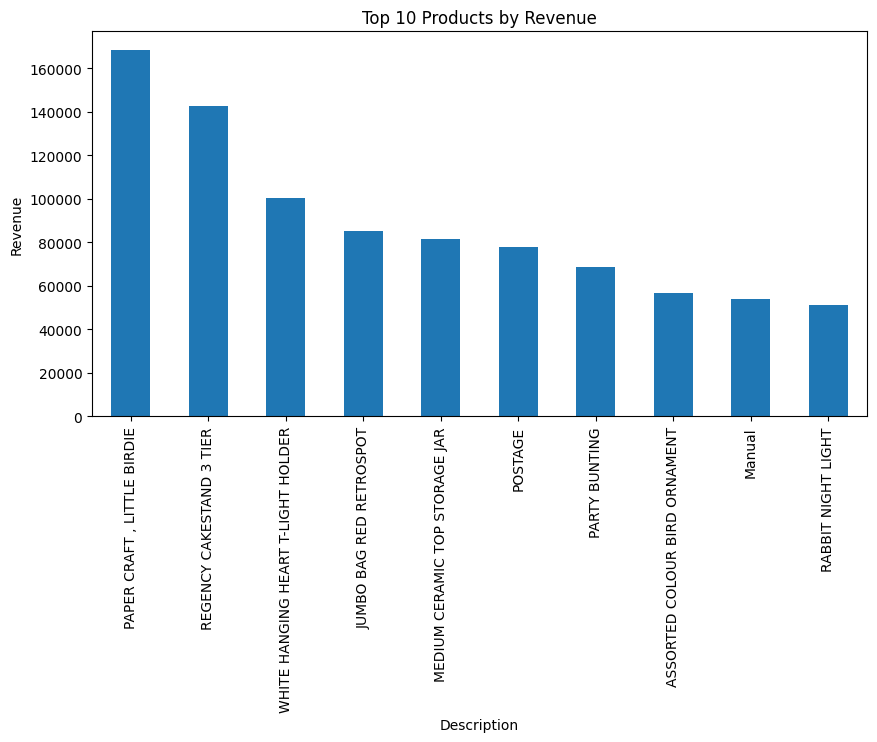

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: Revenue, dtype: float64


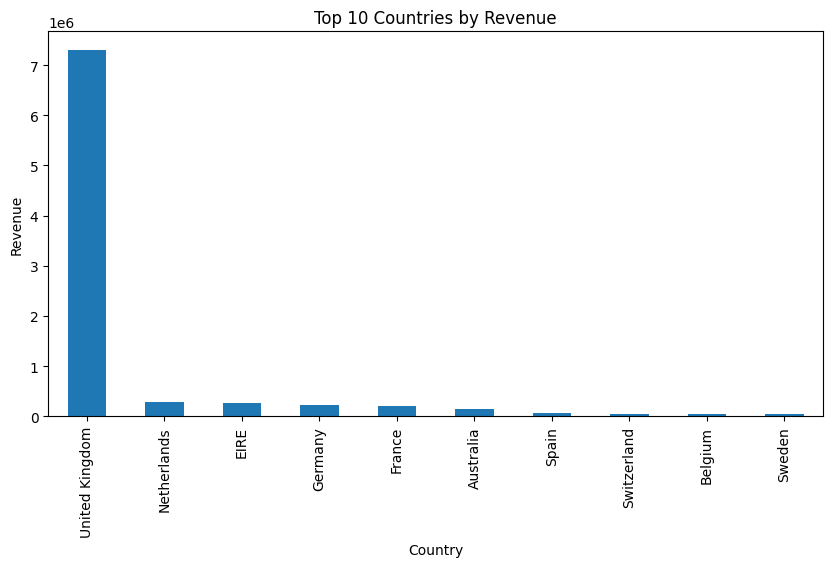

Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: Revenue, dtype: float64


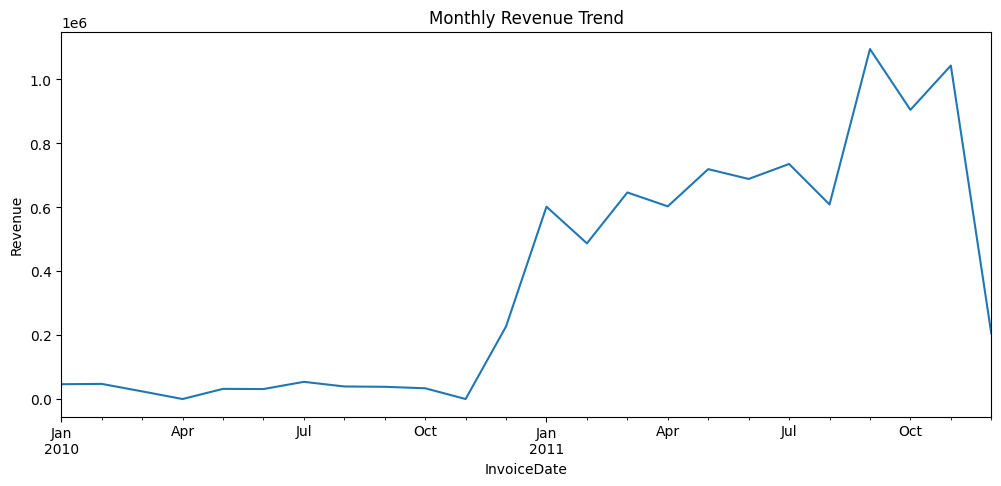

In [11]:
# Step 3: EDA

# Create Revenue column (IMPORTANT for business analysis)
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# -------------------------------
# 1. Top 10 products by revenue
# -------------------------------
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_products.plot(kind='bar')
plt.title("Top 10 Products by Revenue")
plt.ylabel("Revenue")
plt.show()

print(top_products)

# -------------------------------
# 2. Revenue by country
# -------------------------------
revenue_country = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
revenue_country.plot(kind='bar')
plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue")
plt.show()

print(revenue_country)

# -------------------------------
# 3. Monthly Revenue Trend
# -------------------------------
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df.set_index('InvoiceDate', inplace=True)

monthly_revenue = df['Revenue'].resample('ME').sum()

plt.figure(figsize=(12,5))
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()

# Reset index (IMPORTANT for next steps)
df.reset_index(inplace=True)

# Push to GitHub
push_to_github("Step 3: EDA completed")

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: Revenue, dtype: float64
Country
United Kingdom    3920
Germany             94
France              87
Spain               30
Belgium             25
Switzerland         21
Portugal            19
Italy               14
Finland             12
Austria             11
Name: CustomerID, dtype: int64


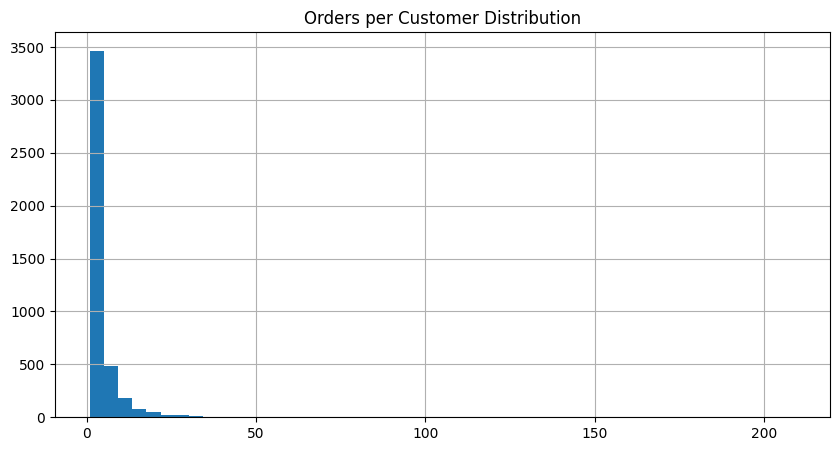

In [12]:
# Step 4: Customer Analysis

# Total revenue per customer
customer_revenue = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False)

print(customer_revenue.head(10))

# Number of unique customers per country
customers_country = df.groupby('Country')['CustomerID'].nunique().sort_values(ascending=False)

print(customers_country.head(10))

# Orders per customer
orders_per_customer = df.groupby('CustomerID')['InvoiceNo'].nunique()

plt.figure(figsize=(10,5))
orders_per_customer.hist(bins=50)
plt.title("Orders per Customer Distribution")
plt.show()

# Push to GitHub
push_to_github("Step 4: Customer analysis completed")

In [13]:
# Step 5: RFM Analysis

# Snapshot date (last date in dataset + 1)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

print(rfm.head())

# Scoring (1–5 scale)
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

print(rfm.head())

# Push to GitHub
push_to_github("Step 5: RFM analysis completed")

            Recency  Frequency  Monetary
CustomerID                              
12346.0         327          1  77183.60
12347.0          41          7   4310.00
12348.0          77          4   1797.24
12349.0          20          1   1757.55
12350.0         312          1    334.40
            Recency  Frequency  Monetary R_score F_score M_score RFM_Score
CustomerID                                                                
12346.0         327          1  77183.60       1       1       5       115
12347.0          41          7   4310.00       4       5       5       455
12348.0          77          4   1797.24       3       4       4       344
12349.0          20          1   1757.55       4       1       4       414
12350.0         312          1    334.40       1       1       2       112


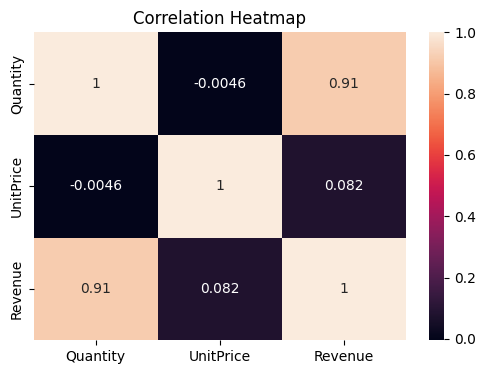

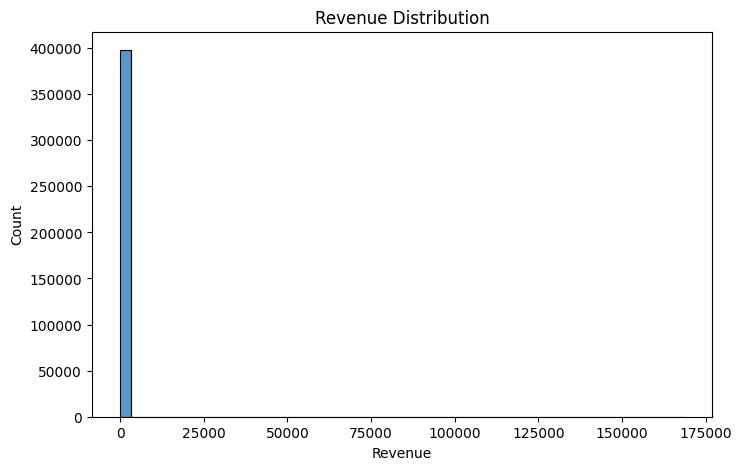

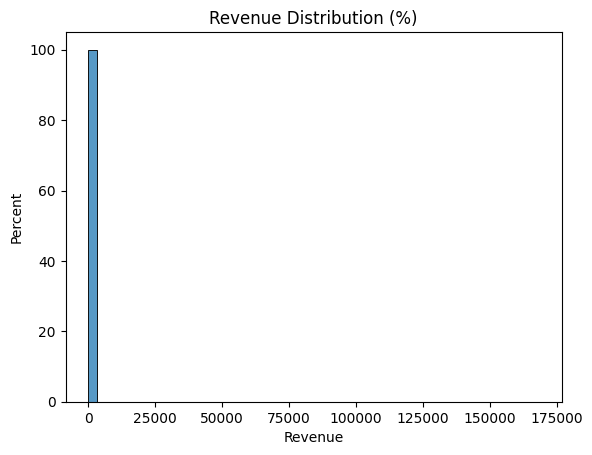

In [15]:
# Step 6: Visualization

# Heatmap for correlation
plt.figure(figsize=(6,4))
sns.heatmap(df[['Quantity','UnitPrice','Revenue']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Revenue distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Revenue'], bins=50)
plt.title("Revenue Distribution")
plt.show()

sns.histplot(df['Revenue'], bins=50, stat="percent")
plt.title("Revenue Distribution (%)")
plt.show()

# Push to GitHub
push_to_github("Step 6: Visualization completed")